# Regresión Logística

## Introducción

La regresión logistica es un algoritmo de clasificación ampliamente utilizado en machine learning. Aunque su nombre sugiere que es un método de regresión, en realidad se utiliza para problemas de clasificación binaria o multiclase. En este tutorial, implementaremos una regresión logística utilizando la librería `scikit-learn` y seguiremos todas las etapas del pipeline de machine learning.

## Fundamentos

La regresión logística es un modelo de clasificación probabilística. En lugar de predecir un número real, estima la probabilidad de pertenecer a una clase a partir de una combinación lineal de las variables de entrada y una función sigmoide que convierte ese valor en una probabilidad entre 0 y 1. En binario, si la probabilidad supera un umbral (típicamente 0.5), asigna la clase positiva.

## Modelo Matemático

Se define un score lineal $z = w_0 + w_1x_1 + \dots + w_nx_n$ y aplica la sigmoide:

$$
P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Equivalentemente, modela los **log-odds** (logit) de la clase positiva como lineales en $x$:

$$
\log \frac{P(y=1 \mid x)}{1 - P(y=1 \mid x)} = w_0 + w_1x_1 + \dots + w_nx_n
$$

Los parámetros $w$ se ajustan **maximizando la (log) verosimilitud** sobre los datos (o, en la práctica, **minimizando la pérdida logarítmica** con regularización). Ver: sigmoide y logit; construcción de la función de verosimilitud; forma Bernoulli $p_i^{y_i}(1 - p_i)^{1-y_i}$; y actualización por gradiente.
## Descripción de librerías, clases, funciones y parámetros

* `pandas` (pd): carga y manipulación del dataset (read_csv, DataFrame).
* `numpy` (np): operaciones numéricas.
* `matplotlib.pyplot` (plt) y `seaborn` (sns): visualización (histogramas, dispersión, curvas).
* `sklearn.linear_model.LogisticRegression`
    * `solver` (`lbfgs`, `liblinear`, etc.), `penalty` (`l2` por defecto), `C` (inversa de la regularización; menor `C` = más regularización), `max_iter`.
    * Métodos: `fit`, `predict`, `predict_proba`, `decision_function`.
* `sklearn.model_selection.train_test_split`: separación de entrenamiento/prueba (usar `stratify=y` en clasificación binaria para mantener proporciones).
* `sklearn.preprocessing.StandardScaler`: **recomendado** porque la LR usa una penalización $L_2$ y la optimización mejora con variables escaladas.
* `sklearn.pipeline.Pipeline`: encadena escalado $\rightarrow$ modelo y evita fugas de datos.
* **Métricas:** `confusion_matrix`, `accuracy_score`.


# **Pipeline**

## **+ Preprocesamiento**
En esta etapa se realiza un análisis exploratorio del dataset con el fin de comprender su estructura, distribución y comportamiento general antes de aplicar el modelo de regresión logística.

El objetivo es conocer las características más relevantes y observar si existe una posible relación entre las variables de entrada y la variable objetivo

Para ello se utiliza:
* df.describe() para obtener estadísticas básicas: media, desviación estándar, valores mínimos y máximos de cada variable.

* sns.countplot() para visualizar la distribución de las clases y verificar si están balanceadas.

* sns.scatterplot() para mostrar un gráfico de dispersión entre dos variables relevantes y observar si existe separación entre clases, lo cual puede indicar que el modelo logístico será capaz de encontrar un límite de decisión adecuado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Cargar dataset de cáncer de mama (binario: 0 = malignant, 1 = benign)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0/1


In [3]:
# Estadísticas básicas de las características
X.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


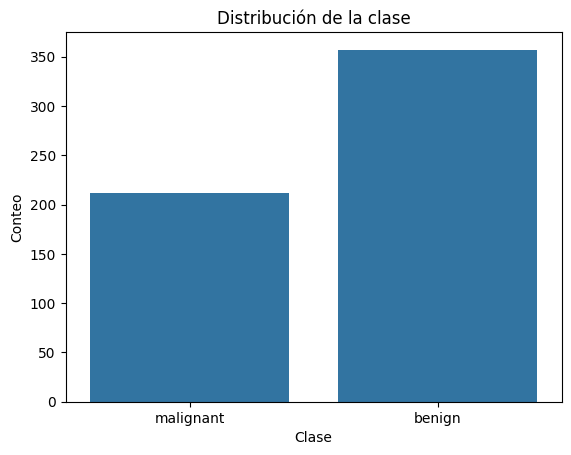

In [2]:
# Distribución de la clase
sns.countplot(x=y.map({0: 'malignant', 1: 'benign'}))
plt.title('Distribución de la clase')
plt.xlabel('Clase')
plt.ylabel('Conteo')
plt.show()


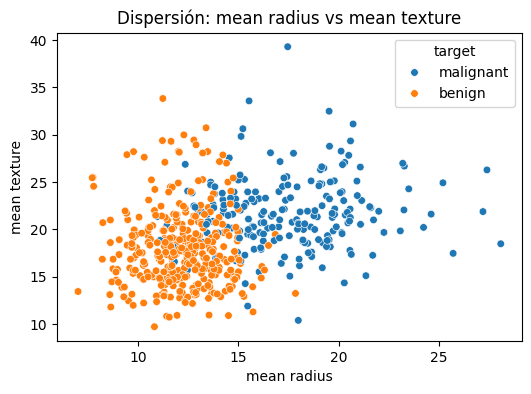

In [4]:
# Gráfico de dispersión entre dos variables representativas
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=X["mean radius"],
    y=X["mean texture"],
    hue=y.map({0: 'malignant', 1: 'benign'}),
    s=30
)
plt.title('Dispersión: mean radius vs mean texture')
plt.xlabel('mean radius')
plt.ylabel('mean texture')
plt.show()


Este análisis permite observar si hay separación entre clases, lo cual sugiere que un modelo lineal puede funcionar.

## **+ Feature Engineering**

Aquí se preparan las variables que usará el modelo:

* X (entradas): todas las características numéricas del dataset.

* y (salida): la clase (0 = maligno, 1 = benigno).

* Se divide el dataset en entrenamiento y prueba.

* Se aplica escalado con StandardScaler, para que todas las características estén en una escala similar (muy importante para la regresión logística).

In [5]:
# Separar en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (fit en train, transform en train y test)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


- Escalar es importante porque algunas variables tienen valores muy grandes y otras pequeños; si no se escalan, pueden dominar el entrenamiento del modelo.

## **+ Model Selection**

#### En esta etapa se justifica por qué usamos Regresión Logística y cómo elegimos sus hiperparámetros.

Usamos Regresión Logística porque:

* Es un modelo pensado para clasificación binaria, justo como el problema de cáncer de mama (0 = malignant, 1 = benign).

* No solo da una clase, sino una probabilidad, lo que permite interpretar qué tan segura es la predicción.

Se eligió regresión logística porque es simple, rápida y produce probabilidades interpretables; otros modelos como KNN requieren más datos y no producen una función probabilística directa.


## **+ Model Training**

In [6]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_sc, y_train)


LogisticRegression(max_iter=10000)



## **+ Prediction**

Creamos una función que acepte un diccionario con (sub)conjunto de features o una fila de DataFrame con el mismo orden/columnas que X.

In [7]:
def predecir_paciente(model, scaler, sample):

    if isinstance(sample, dict):
        sample = pd.Series(sample)
    # Asegurar mismo orden de columnas que X
    row = sample.reindex(X.columns).astype(float).to_frame().T

    # Escalar con el mismo scaler usado en el entrenamiento
    row_sc = scaler.transform(row)

    # Probabilidad de clase 1 (benign)
    prob = model.predict_proba(row_sc)[0, 1]
    pred = model.predict(row_sc)[0]

    clase = 'benign' if pred == 1 else 'malignant'
    print(f"Clase predicha: {clase} (pred = {pred})")
    print(f"Probabilidad de ser benign: {prob:.3f}")
    return pred, prob

# Ejemplo con un paciente real del conjunto de prueba
ejemplo = X_test.iloc[0]
predecir_paciente(model, scaler, ejemplo)


Clase predicha: malignant (pred = 0)
Probabilidad de ser benign: 0.000


(np.int64(0), np.float64(5.8882418607058976e-08))




## **+ Model Evaluation**

##### Qué medimos:

- Matriz de confusión: aciertos/errores por clase (diagonal = aciertos).
- Accuracy: proporción de aciertos globales.
- Reporte de clasificación: precision, recall y F1 por clase (derivan de TP/FP/FN y muestran dónde hay confusiones).

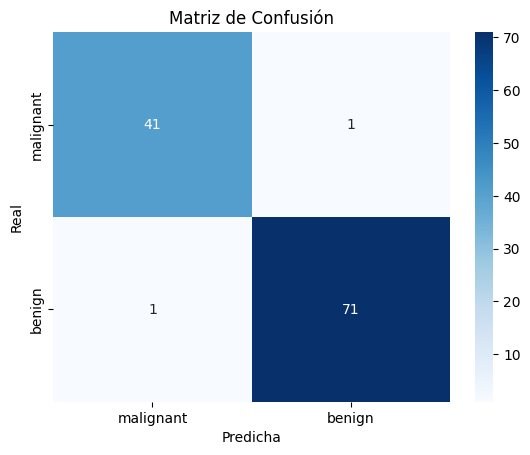

Accuracy: 0.9825

Reporte de clasificación:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [8]:
y_pred = model.predict(X_test_sc)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)



sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['malignant','benign'],
    yticklabels=['malignant','benign']
)
plt.xlabel('Predicha')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

print(f"Accuracy: {acc:.4f}")
# reporte
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=['malignant','benign']))


La matriz de confusión muestra cuántas veces el modelo acertó o se equivocó por clase. El accuracy indica el porcentaje total de aciertos.
- Diagonal = aciertos; fuera de la diagonal = confusiones entre clases.
- Si la diagonal de la matriz tiene números altos y fuera de la diagonal son bajos, el modelo acierta con alta frecuencia.
- Accuracy cercano a 1.00 sugiere muy buen desempeño global en la detección de Cáncer.
- En el reporte, valores altos de precision/recall/F1 para cada clase indican que el modelo casi no confunde las especies.




## **Referencias**
- Gautham, G. (2025, 20 Sep). Logistic Regression for Classification Explained Simply with Python.Medium

- Aurora A. (2023, 25 Jul). Logistic Regression: Maximum Likelihood Estimation & Gradient Descent.Medium.

- Aviña Méndez, J. A. (2025, March 19). Regresión Logística. TSJZapopan.
